The following code presents the process of a restaurant business revenue process. The Business requirement of this problem is the stakeholders (e.g., restaurant owener(s)) want to evaluate the total amount of revue and tipcs for a given period and predict the future earnings for the restaurant based on the existing data. Future prediction of will also help the Business to manage the capacity planning decisions, such as busy day requires more staffs at the restaurants and less number of staffs help in cost cutting during quite days. 

So, the Business owners seek assistance from the data scientist to develop a revuenue analysis system and the objective of the project could be "Collecting and analysing revenue and tips related data to understand the factors influcing them". To acheive this objective DS should collect existing data from restuarant's data base, which are the total tips per day, ethnicity of the customer, number of customers per table per day, etc.

In [6]:

#import all essential libraries
import pandas as pd # for handling datasets (tables)
import numpy as np # for handling numerical operations


In [7]:
# now load the dataset for restaurant revenue
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv" #first copy the url to url variable
df = pd.read_csv(url) # use pandas function to load the restaurant revenue data from the url

df.head() #show the first five rows from the table/data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
# Now dataset is ready to be investigated
df.shape
#It tells us the size of the dataset, i.e., number of rows and columns in a table
#It has 244 observations and 7 variables (rows and columns)

(244, 7)

In [9]:
df.info () #tells us the data types for each variable
#int and float for numerical values and object is for categorical variables (qualitative)
#data types of all variables can be obtained by df.info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [10]:
#Now do the descriptive statistics, i.e., check the mean, max, min, standard dev. of the data
df.describe()
#It can also be defined as descriptive analysis
#for example 25% of the total bills per day are is 13.347
#mean is 19.78 and tip is 2.99

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [11]:
#now check if there is any missing values
#it tell us the total number of missing values for each variable
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [12]:
#identify the duplicated values
df.duplicated().sum()
#only one value is found to be duplicated

np.int64(1)

In [13]:
#drop the duplicated values
df.drop_duplicates()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [14]:
# Rename column headings the name of the column headings
df.columns
df.rename(columns={"total_bills":"total_bills_amount"}, inplace=True)

In [15]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [16]:
#First, the headings of the columns can be checked using the following code
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [17]:
#Now, if we want to modify the column heading then we can use the following code
df.rename (columns= {"tip":"tip_amount"}, inplace=True)

In [18]:
#Now we can check if the change has been done correctly or not
df.columns

Index(['total_bill', 'tip_amount', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [23]:
# Now, additional variables are added for further analysis (Feature Engineering)
#Add percentage of tips
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv" #first copy the url to url variable
df = pd.read_csv (url)

df["tips_percentage"]=(df["tip"]/df["total_bill"])*100

In [24]:
#Now, check if the heading to verify if the new column is added or not
df.head()

,total_bill,tip,sex,smoker,day,time,size,tips_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [28]:
sum_tip_percentage = df["tips_percentage"].sum()


In [29]:
print (sum_tip_percentage)

3923.582994029115


In [32]:
avg_tip_percentage = sum_tip_percentage/df.shape[0]

In [33]:
print (avg_tip_percentage)

16.08025817225047


In [36]:
Avg_tip_percentage = df["tips_percentage"].mean()

In [37]:
print (Avg_tip_percentage)

16.08025817225047


In [38]:
#Exploratory Data Analytics

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='total_bill', ylabel='tip'>

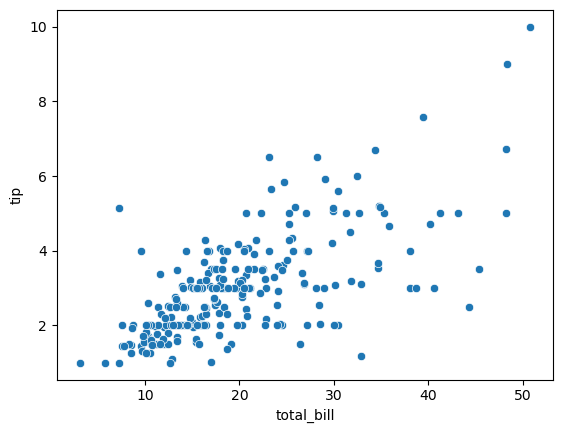

In [44]:
sns.scatterplot (x = "total_bill", y="tip", data=df)

In [ ]:
#Higher total bills tend to produce higher tips

<Axes: xlabel='day', ylabel='total_bill'>

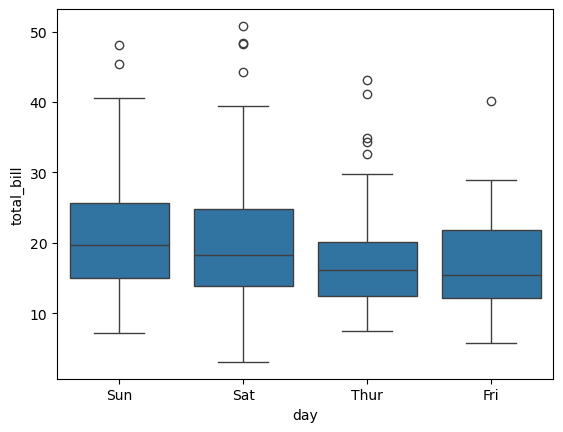

In [46]:
sns.boxplot (x="day", y="total_bill", data=df)

In [57]:
# Total Bill amount have higher standard deviation in Sunday and lower in Friday
# Sunday has the higher total bill on average

<Axes: xlabel='day', ylabel='tip'>

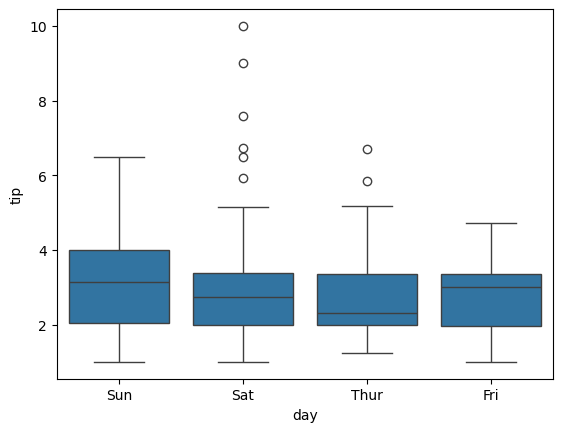

In [47]:
sns.boxplot(x="day", y="tip", data=df)

<Axes: xlabel='tips_percentage', ylabel='Count'>

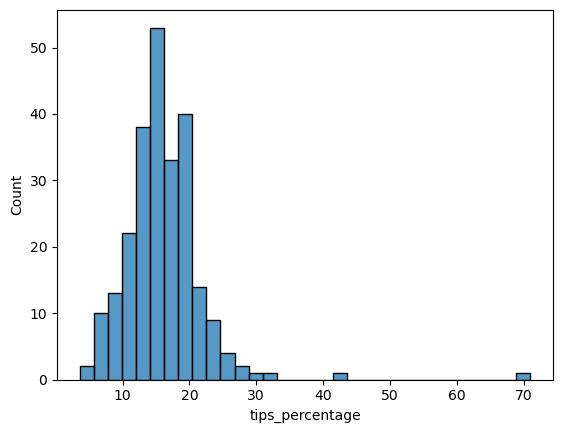

In [50]:
sns.histplot(df["tips_percentage"])

In [ ]:
#Percentage of tip (tips per total bill) is a smooth uniform distribution with the mean near

<Axes: xlabel='size', ylabel='Count'>

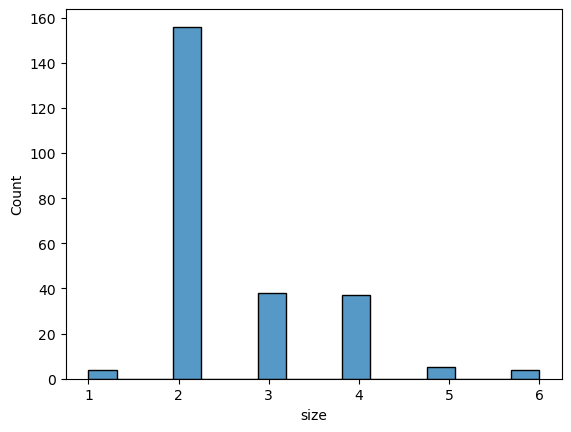

In [54]:
sns.histplot(df["size"])


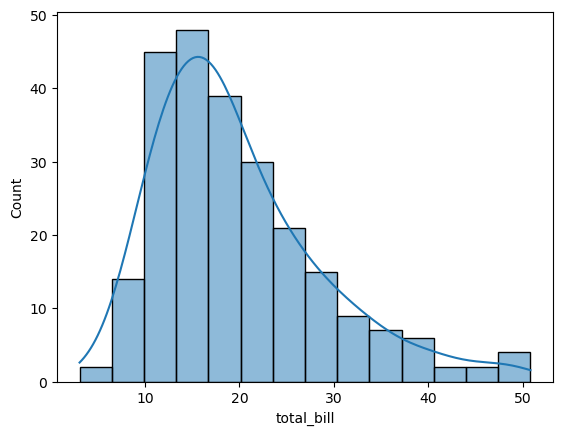

In [55]:
sns.histplot(df["total_bill"], kde=True)
plt.show()


In [ ]:
Total bill mean near $15 with slightly inclinations towards left

<Axes: xlabel='tip', ylabel='Count'>

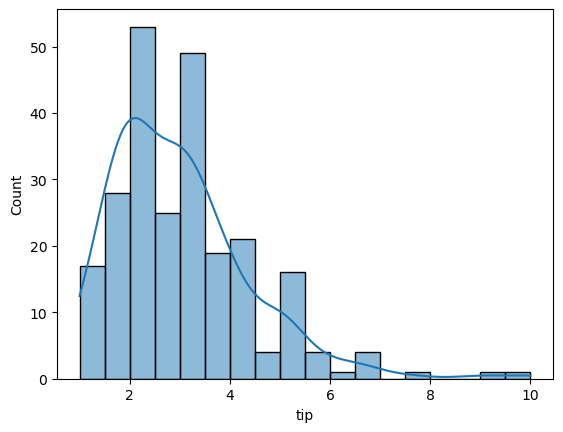

In [56]:
sns.histplot(df["tip"],kde =True)

In [58]:
#Mean value of the total tip is near $2 although the distribution is not completely uniform in bothsides of the mean